# 07 — Curse of dimensionality

More features do not automatically mean more information. We progressively add 100 ALA features,
168 phase-dynamics features, sparse raw values, derivatives, spectral values, and 1,000 explicitly
irrelevant controls to k-NN. In high dimensions, standardized Euclidean distances become more
similar and the idea of a “nearest” neighbor loses contrast.

## Software, distance model, and parameters

The experiment adds ALA, phase dynamics, sparse raw values, derivatives, spectra, and explicitly
irrelevant Gaussian controls to distance-weighted k-NN. `k` is selected once on the compact ALA
baseline and then held fixed. Every column is standardized from training statistics so units do
not dominate Euclidean distance. The control features contain no target information; they expose
how irrelevant dimensions dilute meaningful neighborhoods.

In [1]:
GAS = "hydrogen"
N_ALA_SEGMENTS = 50
N_NOISE_FEATURES = 1000
RANDOM_STATE_DEMO = 73

In [2]:
from pathlib import Path
from html import escape
import sys
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from sklearn.neighbors import KNeighborsRegressor

HERE = Path.cwd()
if not (HERE / "dataset_pipeline.py").exists():
    HERE = HERE / "Evaluation Seminar" / "Day_02"
sys.path.insert(0, str(HERE.resolve()))

from dataset_pipeline import *
from physics_features import (
    extract_ala_features,
    extract_phase_features,
    learn_ala_breakpoints,
)

if GAS not in GAS_TARGETS:
    raise ValueError(f"Unknown gas: {GAS}")
plt.style.use("seaborn-v0_8-whitegrid")
splits = prepare_splits("stored")

def show_table(rows, columns, digits=3):
    def formatted(value):
        if isinstance(value, (float, np.floating)):
            return f"{value:.{digits}f}"
        return str(value)
    header = "".join(f"<th>{escape(column)}</th>" for column in columns)
    body = "".join(
        "<tr>" + "".join(
            f"<td>{escape(formatted(row[column]))}</td>" for column in columns
        ) + "</tr>" for row in rows
    )
    display(HTML(f"<table><thead><tr>{header}</tr></thead><tbody>{body}</tbody></table>"))

## 1. Build feature blocks

ALA boundaries use the training median only. Raw signals and derivatives are subsampled; the
spectrum uses the first 256 non-DC real-FFT magnitudes. Reproducible Gaussian controls contain
no target information and show what happens when dimensions are added without selection.

In [3]:
train_reference = np.median(splits["train"]["X"][:, 0, :], axis=0)
ala_breakpoints = learn_ala_breakpoints(
    train_reference, n_segments=N_ALA_SEGMENTS
)

blocks = {split: {} for split in SPLIT_NAMES}
for split_number, split in enumerate(SPLIT_NAMES):
    raw = splits[split]["X"][:, 0, :].astype(float)
    ala, ala_names = extract_ala_features(
        splits[split]["X"], ala_breakpoints
    )
    phase, phase_names = extract_phase_features(splits[split]["X"])
    raw_sparse = raw[:, ::4]
    derivative_sparse = np.diff(raw, axis=1)[:, ::4]
    spectrum = np.abs(np.fft.rfft(raw - raw.mean(axis=1, keepdims=True), axis=1))
    spectrum = np.log1p(spectrum[:, 1:257])
    rng = np.random.default_rng(RANDOM_STATE_DEMO + split_number)
    noise = rng.normal(size=(len(raw), N_NOISE_FEATURES))

    blocks[split] = {
        "ALA": ala,
        "Phase dynamics": phase,
        "Raw signal / 4": raw_sparse,
        "Derivative / 4": derivative_sparse,
        "Spectrum": spectrum,
        "Irrelevant controls": noise,
    }

block_rows = [
    {"Feature block": name, "Count": values.shape[1]}
    for name, values in blocks["train"].items()
]
show_table(block_rows, ["Feature block", "Count"], digits=0)

Feature block,Count
ALA,100
Phase dynamics,168
Raw signal / 4,360
Derivative / 4,360
Spectrum,256
Irrelevant controls,1000


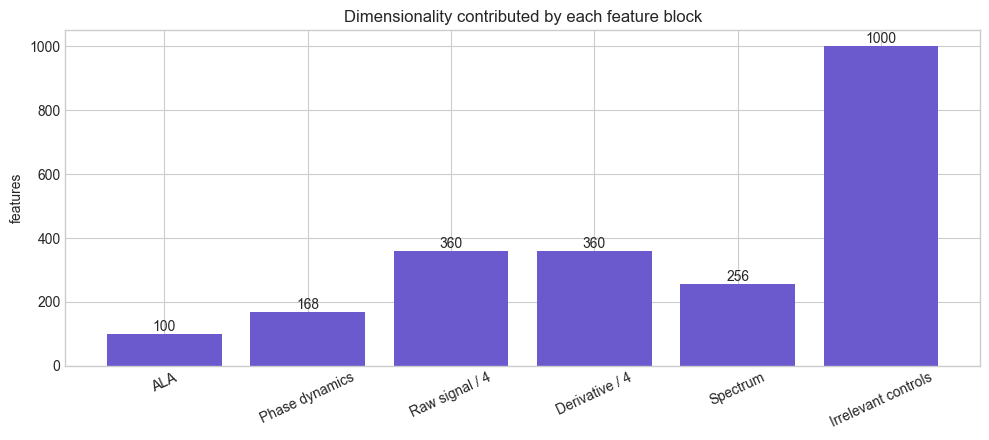

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
block_names = [row["Feature block"] for row in block_rows]
block_sizes = [row["Count"] for row in block_rows]
bars = ax.bar(block_names, block_sizes, color="slateblue")
ax.bar_label(bars)
ax.set(title="Dimensionality contributed by each feature block", ylabel="features")
ax.tick_params(axis="x", rotation=25)
plt.tight_layout()

## 2. Select k on the compact ALA baseline only

In [5]:
def standardize(feature_dict):
    mean = feature_dict["train"].mean(axis=0)
    scale = feature_dict["train"].std(axis=0)
    scale[scale < 1e-12] = 1.0
    return {
        split: (feature_dict[split] - mean) / scale
        for split in SPLIT_NAMES
    }

ala_only = {
    split: blocks[split]["ALA"] for split in SPLIT_NAMES
}
ala_scaled = standardize(ala_only)
y_train = splits["train"]["targets"][GAS].astype(float)
y_val = splits["val"]["targets"][GAS].astype(float)

def r2(y_true, prediction):
    residual = np.asarray(y_true) - np.asarray(prediction)
    return 1 - np.sum(residual ** 2) / np.sum(
        (y_true - np.mean(y_true)) ** 2
    )

k_trials = []
for k in (3, 5, 7, 11, 21, 31):
    candidate = KNeighborsRegressor(n_neighbors=k, weights="distance")
    candidate.fit(ala_scaled["train"], y_train)
    score = r2(y_val, candidate.predict(ala_scaled["val"]))
    k_trials.append({"k": k, "Validation R2": score})
BEST_K = max(k_trials, key=lambda row: row["Validation R2"])["k"]
show_table(k_trials, ["k", "Validation R2"])
print("Fixed k for all following dimensions:", BEST_K)

k,Validation R2
3,0.712
5,0.737
7,0.751
11,0.754
21,0.752
31,0.737


Fixed k for all following dimensions: 11


## 3. Progressively overload the model with features

In [6]:
stage_definitions = [
    ("ALA", ["ALA"]),
    ("+ Phase dynamics", ["ALA", "Phase dynamics"]),
    ("+ raw signal", ["ALA", "Phase dynamics", "Raw signal / 4"]),
    ("+ derivative", [
        "ALA", "Phase dynamics", "Raw signal / 4", "Derivative / 4"
    ]),
    ("+ Spectrum", [
        "ALA", "Phase dynamics", "Raw signal / 4",
        "Derivative / 4", "Spectrum"
    ]),
    ("+ 1000 irrelevant", list(blocks["train"])),
]

def regression_metrics(y_true, prediction):
    residual = np.asarray(y_true) - np.asarray(prediction)
    mse = float(np.mean(residual ** 2))
    return {
        "R2": r2(y_true, prediction),
        "RMSE": np.sqrt(mse),
        "MAE": float(np.mean(np.abs(residual))),
    }

stage_results = []
stage_models = {}
stage_scaled = {}
for stage_name, block_names in stage_definitions:
    feature_dict = {
        split: np.column_stack([
            blocks[split][block_name] for block_name in block_names
        ])
        for split in SPLIT_NAMES
    }
    scaled = standardize(feature_dict)
    model = KNeighborsRegressor(
        n_neighbors=BEST_K,
        weights="distance",
        metric="minkowski",
        p=2,
    )
    model.fit(scaled["train"], y_train)
    stage_models[stage_name] = model
    stage_scaled[stage_name] = scaled
    for split in SPLIT_NAMES:
        prediction = model.predict(scaled[split])
        stage_results.append({
            "Stufe": stage_name,
            "Features": scaled["train"].shape[1],
            "Split": split,
            **regression_metrics(
                splits[split]["targets"][GAS].astype(float), prediction
            ),
        })

show_table(
    stage_results,
    ["Stufe", "Features", "Split", "R2", "RMSE", "MAE"],
)

Stufe,Features,Split,R2,RMSE,MAE
ALA,100,train,1.000,0.000,0.000
ALA,100,val,0.754,225.684,177.806
ALA,100,test,0.738,237.534,191.270
ALA,100,test_extra,-0.072,477.483,388.887
+ Phase dynamics,268,train,1.000,0.000,0.000
+ Phase dynamics,268,val,0.739,232.553,187.178
+ Phase dynamics,268,test,0.711,249.319,199.064
+ Phase dynamics,268,test_extra,-0.110,485.919,395.459
+ raw signal,628,train,1.000,0.000,0.000
+ raw signal,628,val,0.692,252.418,199.693


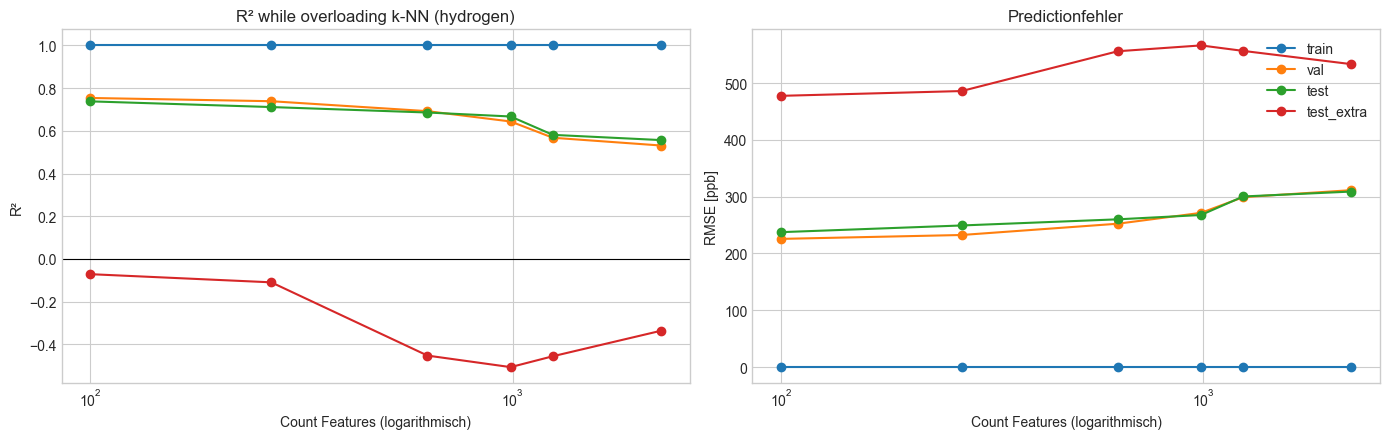

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for split in ("train", "val", "test", "test_extra"):
    subset = [row for row in stage_results if row["Split"] == split]
    axes[0].plot(
        [row["Features"] for row in subset],
        [row["R2"] for row in subset],
        marker="o",
        label=split,
    )
    axes[1].plot(
        [row["Features"] for row in subset],
        [row["RMSE"] for row in subset],
        marker="o",
        label=split,
    )
for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Count Features (logarithmisch)")
axes[0].set(title=f"R² while overloading k-NN ({GAS})", ylabel="R²")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[1].set(title="Predictionfehler", ylabel="RMSE [ppb]")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Distances lose contrast

Stufe,Features,Mean nearest distance,Mean farthest distance,Relative contrast
ALA,100,4.322,28.575,0.844
+ Phase dynamics,268,9.388,43.774,0.780
+ raw signal,628,9.953,72.093,0.858
+ derivative,988,28.226,77.746,0.629
+ Spectrum,1244,32.261,86.371,0.620
+ 1000 irrelevant,2244,54.748,97.427,0.432


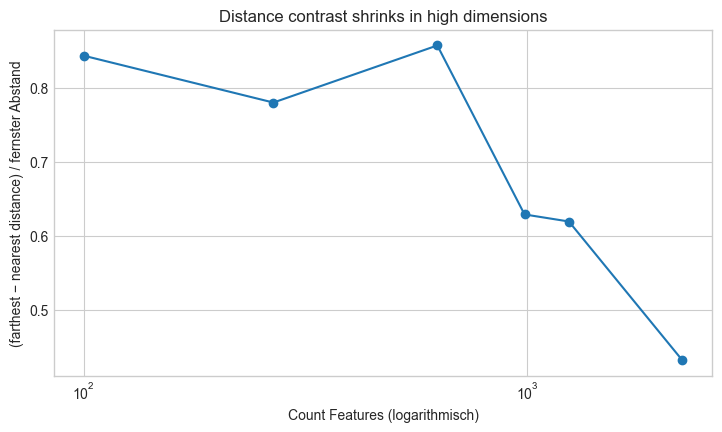

In [8]:
distance_rows = []
for stage_name, _ in stage_definitions:
    scaled = stage_scaled[stage_name]
    query = scaled["val"][:100]
    reference = scaled["train"][:300]
    squared = (
        np.sum(query ** 2, axis=1)[:, None]
        + np.sum(reference ** 2, axis=1)[None, :]
        - 2 * query @ reference.T
    )
    distances = np.sqrt(np.maximum(squared, 0))
    nearest = distances.min(axis=1)
    farthest = distances.max(axis=1)
    distance_rows.append({
        "Stufe": stage_name,
        "Features": scaled["train"].shape[1],
        "Mean nearest distance": nearest.mean(),
        "Mean farthest distance": farthest.mean(),
        "Relative contrast": np.mean((farthest - nearest) / farthest),
    })

show_table(distance_rows, list(distance_rows[0]))
fig, ax = plt.subplots(figsize=(8.5, 4.5))
ax.plot(
    [row["Features"] for row in distance_rows],
    [row["Relative contrast"] for row in distance_rows],
    marker="o",
)
ax.set_xscale("log")
ax.set(
    xlabel="Count Features (logarithmisch)",
    ylabel="(farthest − nearest distance) / fernster Abstand",
    title="Distance contrast shrinks in high dimensions",
)
plt.show()

## 5. Scatter plot: compact versus fully overloaded

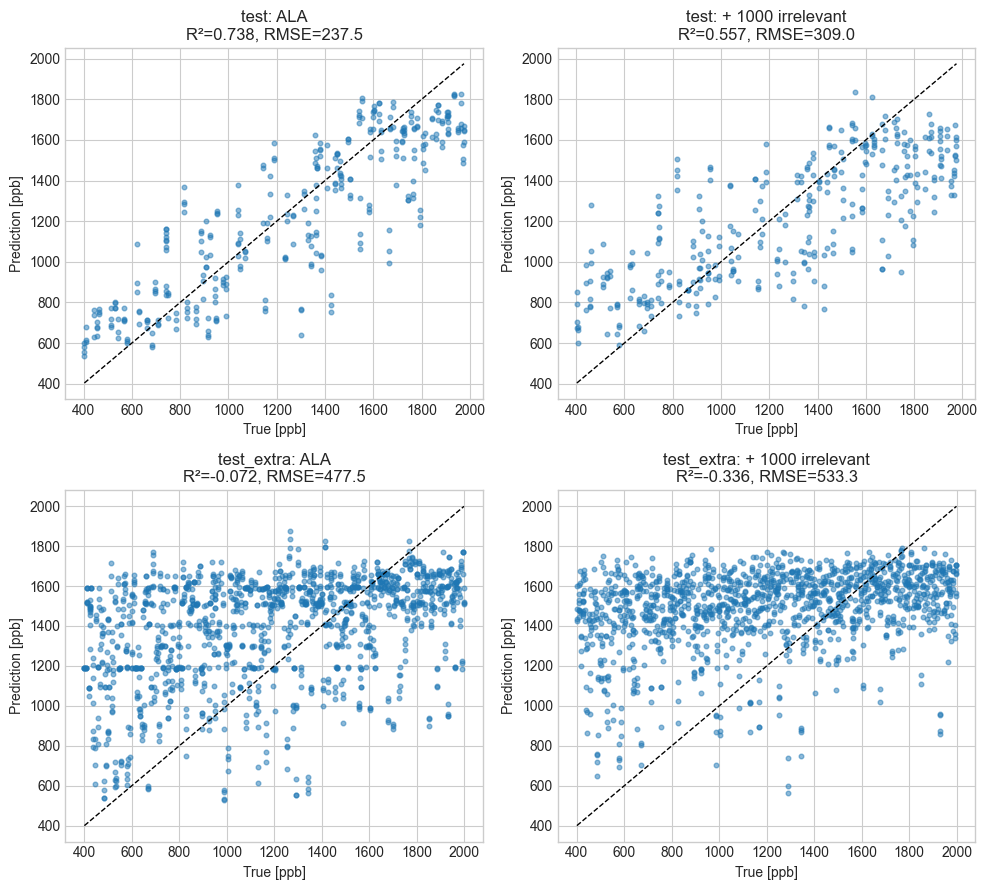

In [9]:
comparison_stages = ("ALA", "+ 1000 irrelevant")
comparison_splits = ("test", "test_extra")
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for row, split in enumerate(comparison_splits):
    truth = splits[split]["targets"][GAS].astype(float)
    for column, stage_name in enumerate(comparison_stages):
        prediction = stage_models[stage_name].predict(
            stage_scaled[stage_name][split]
        )
        score = regression_metrics(truth, prediction)
        lower = min(float(truth.min()), float(prediction.min()))
        upper = max(float(truth.max()), float(prediction.max()))
        ax = axes[row, column]
        ax.scatter(truth, prediction, s=11, alpha=0.5)
        ax.plot([lower, upper], [lower, upper], "k--", linewidth=1)
        ax.set(
            xlabel="True [ppb]", ylabel="Prediction [ppb]",
            title=(
                f"{split}: {stage_name}\n"
                f"R²={score['R2']:.3f}, RMSE={score['RMSE']:.1f}"
            ),
        )
plt.tight_layout()
plt.show()

## Conclusion

Distance-weighted k-NN has perfect training R² because every training row is its own nearest
neighbor, yet validation and test performance can deteriorate. Irrelevant standardized dimensions
contribute as much to distance as useful ones, dilute meaningful neighborhoods, and make nearest
and farthest points relatively more alike. Real projects need feature selection, regularization,
or dimensionality reduction evaluated on completely held-out UGM groups.